In [1]:
def fmp_historical(ticker):
    key = open('auth.txt','r').read()
    return f'https://financialmodelingprep.com/stable/historical-price-eod/light?symbol={ticker}&apikey={key}'

# Volatility Forecast with PyTorch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
import torch.optim as optim
import asyncio


In [3]:
stocks = ['AAPL','MSFT','NVDA','GOOGL','SPY','GS']

In [4]:
close = []
for stock in stocks:
    resp = requests.get(fmp_historical(stock)).json()
    df = pd.DataFrame(resp)
    df = df['price'][::-1].values.tolist()[-365:]
    close.append(df)
    await asyncio.sleep(1.2)
    print(stock, ' has loaded')

close = np.array(close).T

AAPL  has loaded
MSFT  has loaded
NVDA  has loaded
GOOGL  has loaded
SPY  has loaded
GS  has loaded


In [5]:
returns = close[1:] / close[:-1] - 1.0
mu = np.mean(returns, axis=0)
cv = np.cov(returns.T)
cv.shape

(6, 6)

In [6]:
A = np.linalg.inv(cv).dot(mu)
b = A.dot(np.ones(len(mu)))
w = A / b
print(w)

[-0.12599733  4.77933117 -3.33925249 -9.64875693 17.67129859 -8.33662301]


In [7]:
portfolio = returns @ w
portfolio

array([ 3.73293470e-02, -1.22429549e-01, -5.17650601e-02, -5.10314510e-02,
       -1.27006313e-01, -6.19239291e-02, -2.57772673e-02,  1.61387902e-01,
       -9.25930076e-02, -1.64852254e-01, -1.11997928e-01, -1.01179069e-02,
       -1.58400729e-01,  1.22245702e-01,  3.57088641e-02, -3.04889357e-02,
        2.23881829e-02,  5.80253431e-02, -9.46642456e-02,  4.29866383e-02,
       -2.03031365e-01, -1.11295984e-01, -2.73684019e-01, -1.85352597e-01,
        2.18688973e-02,  1.66136772e-01, -1.27761668e-01, -1.07168357e+00,
        8.00694724e-02,  9.89926094e-02, -2.72528388e-01, -1.53485554e-04,
        2.00723291e-01,  1.49153093e-01, -1.48942230e-01,  4.32733383e-02,
       -1.37157302e-01,  1.12756152e-01,  3.01818321e-01,  2.81211130e-01,
        4.56081553e-02,  5.52339804e-02, -7.60883017e-02,  1.47281747e-02,
        5.50824786e-02, -2.69218442e-02, -6.16639098e-02,  1.51885181e-01,
       -5.17498867e-02,  5.93113772e-02, -4.05957148e-01, -5.46906780e-01,
        1.44714538e-01,  

In [8]:
class Predictor(nn.Module):
    def __init__(self, input_size=50, output_size=1):
        super(Predictor, self).__init__()
        self.nnet = nn.Sequential(
            nn.Linear(input_size, 30),
            nn.ReLU(),
            nn.Linear(30, 10),
            nn.ReLU(),
            nn.Linear(10, output_size)
        )
    def forward(self, x):
        return self.nnet(x)

In [9]:
window = 50
output = 20
model = Predictor(input_size=window, output_size=1)

inputs = []
outputs = []
for i in range(window, len(portfolio)-output+1):
    holdx = portfolio[i-window:i]
    holdy = portfolio[i:i+output]
    inputs.append(holdx)
    outputs.append(np.std(holdy))

X, y = torch.tensor(inputs, dtype=torch.float32), torch.tensor(outputs, dtype=torch.float32)

/tmp/ipykernel_41091/3608622494.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:245.)
  X, y = torch.tensor(inputs, dtype=torch.float32), torch.tensor(outputs, dtype=torch.float32)


In [10]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 150

for epoch in range(epochs):
    outval = model(X)
    loss = criterion(outval, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print("Epoch: ", epoch, " Loss: ", loss.item())

/home/mo/.local/lib/python3.10/site-packages/torch/nn/modules/loss.py:536: UserWarning: Using a target size (torch.Size([295])) that is different to the input size (torch.Size([295, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch:  0  Loss:  0.01311639603227377
Epoch:  10  Loss:  0.005011886358261108
Epoch:  20  Loss:  0.002316042548045516
Epoch:  30  Loss:  0.0020510645117610693
Epoch:  40  Loss:  0.0018187478417530656
Epoch:  50  Loss:  0.0016106611583381891
Epoch:  60  Loss:  0.001546993269585073
Epoch:  70  Loss:  0.001502097467891872
Epoch:  80  Loss:  0.0014783079968765378
Epoch:  90  Loss:  0.0014643188333138824
Epoch:  100  Loss:  0.0014565351884812117
Epoch:  110  Loss:  0.0014511685585603118
Epoch:  120  Loss:  0.0014472948387265205
Epoch:  130  Loss:  0.0014443923719227314
Epoch:  140  Loss:  0.0014420956140384078


In [17]:
with torch.no_grad():
    testout = model(X[-20:])

testout

tensor([[0.1957],
        [0.1975],
        [0.1912],
        [0.1949],
        [0.1963],
        [0.1942],
        [0.1949],
        [0.1912],
        [0.1974],
        [0.1904],
        [0.1947],
        [0.1964],
        [0.1959],
        [0.1955],
        [0.1968],
        [0.1907],
        [0.1985],
        [0.1977],
        [0.1943],
        [0.1962]])

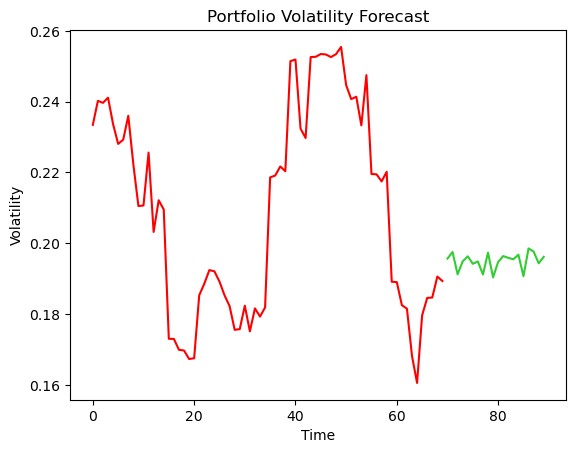

In [18]:
y1 = outputs[-70:]
y2 = testout.numpy()[:, 0]

n1 = len(y1)
n2 = len(y2)

x1 = range(n1)
x2 = range(n1, n1 + n2)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.set_title('Portfolio Volatility Forecast')

ax.plot(x1, y1, color='red')
ax.plot(x2, y2, color='limegreen')

ax.set_xlabel('Time')
ax.set_ylabel('Volatility')

plt.show()